In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
project_dir = r"C:\Users\kjdac\OneDrive\Desktop\PORTFOLIO PROJECTS\Health_Insurance_claims_member_engagement"

processed_dir = os.path.join(project_dir, "data_processed")
outputs_dir = os.path.join(project_dir, "outputs")
tables_dir = os.path.join(outputs_dir, "tables")
charts_dir = os.path.join(outputs_dir, "charts")
tableau_dir = os.path.join(outputs_dir, "tableau_exports")

os.makedirs(outputs_dir, exist_ok=True)
os.makedirs(tables_dir, exist_ok=True)
os.makedirs(charts_dir, exist_ok=True)
os.makedirs(tableau_dir, exist_ok=True)

print("Processed dir:", processed_dir)
print("Tableau export dir:", tableau_dir)

Processed dir: C:\Users\kjdac\OneDrive\Desktop\PORTFOLIO PROJECTS\Health_Insurance_claims_member_engagement\data_processed
Tableau export dir: C:\Users\kjdac\OneDrive\Desktop\PORTFOLIO PROJECTS\Health_Insurance_claims_member_engagement\outputs\tableau_exports


In [3]:
# load scored dataset

df = pd.read_csv(
    os.path.join(processed_dir, "member_features_with_predictions_2010.csv"),
    low_memory=False
)

print("Shape:", df.shape)
df.head()

Shape: (112754, 75)


,DESYNPUF_ID,BENE_BIRTH_DT,BENE_DEATH_DT,BENE_SEX_IDENT_CD,BENE_RACE_CD,BENE_ESRD_IND,SP_STATE_CODE,BENE_COUNTY_CD,BENE_HI_CVRAGE_TOT_MONS,BENE_SMI_CVRAGE_TOT_MONS,...,care_team_messages_90d,scheduled_telehealth_90d,preventive_content_views_90d,engagement_score,engagement_tier,low_engagement_member,outreach_priority_flag,pred_high_cost_probability,pred_high_cost_label,predicted_risk_band
0,00013D2EFD8E45D1,1970-01-01 00:00:00.019230501,NaN,1,1,0,26,950,12,12,...,2,0,4,26.75,Very High,0,0,0.510299,1,High Risk
1,00016F745862898F,1970-01-01 00:00:00.019430101,NaN,1,1,Y,39,230,12,12,...,5,0,5,30.75,Very High,0,0,0.963312,1,Very High Risk
2,0001FDD721E223DC,1970-01-01 00:00:00.019360901,NaN,2,1,0,39,280,12,12,...,0,0,1,8.75,Low,1,0,0.002596,0,Moderate Risk
3,00021CA6FF03E670,1970-01-01 00:00:00.019410601,NaN,1,5,0,6,290,12,12,...,1,0,2,6.25,Low,1,0,0.000140,0,Low Risk
4,00024B3D2352D2D0,1970-01-01 00:00:00.019360801,NaN,1,1,0,52,590,9,12,...,1,0,1,14.75,Medium,0,0,0.003526,0,Moderate Risk


In [4]:
# sanity check

key_cols = [
    "DESYNPUF_ID",
    "high_cost_member",
    "pred_high_cost_probability",
    "predicted_risk_band",
    "engagement_tier",
    "low_engagement_member",
    "outreach_priority_flag"
]

df[key_cols].head()

,DESYNPUF_ID,high_cost_member,pred_high_cost_probability,predicted_risk_band,engagement_tier,low_engagement_member,outreach_priority_flag
0,00013D2EFD8E45D1,0,0.510299,High Risk,Very High,0,0
1,00016F745862898F,1,0.963312,Very High Risk,Very High,0,0
2,0001FDD721E223DC,0,0.002596,Moderate Risk,Low,1,0
3,00021CA6FF03E670,0,0.000140,Low Risk,Low,1,0
4,00024B3D2352D2D0,0,0.003526,Moderate Risk,Medium,0,0


In [5]:
# convert date columns if needed

date_cols = ["BENE_BIRTH_DT", "BENE_DEATH_DT"]

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

In [6]:
# create final business segment label

conditions = [
    (df["high_cost_member"] == 1) & (df["low_engagement_member"] == 1),
    (df["predicted_risk_band"].isin(["High Risk", "Very High Risk"])) & (df["low_engagement_member"] == 0),
    (df["predicted_risk_band"].isin(["Low Risk", "Moderate Risk"])) & (df["low_engagement_member"] == 1),
    (df["predicted_risk_band"].isin(["Low Risk", "Moderate Risk"])) & (df["low_engagement_member"] == 0)
]

choices = [
    "High Cost + Low Engagement",
    "High Risk but Engaged",
    "Lower Risk + Low Engagement",
    "Lower Priority Stable"
]

df["business_segment"] = np.select(conditions, choices, default="Other")

In [7]:
# segment counts

segment_counts = (
    df["business_segment"]
    .value_counts(dropna=False)
    .reset_index()
)

segment_counts.columns = ["business_segment", "member_count"]
segment_counts["member_pct"] = (segment_counts["member_count"] / len(df) * 100).round(2)

segment_counts

,business_segment,member_count,member_pct
0,High Risk but Engaged,53700,47.63
1,Lower Priority Stable,29985,26.59
2,Lower Risk + Low Engagement,26391,23.41
3,Other,1406,1.25
4,High Cost + Low Engagement,1272,1.13


In [8]:
# save segment counts

segment_counts.to_csv(
    os.path.join(tables_dir, "business_segment_counts.csv"),
    index=False
)

print("Saved business segment counts.")

Saved business segment counts.


In [9]:
# business segment summary table

segment_summary = (
    df.groupby("business_segment")[[
        "age_2010",
        "chronic_condition_count",
        "inpatient_claim_count",
        "outpatient_claim_count",
        "total_paid_all_claims",
        "pred_high_cost_probability",
        "engagement_score",
        "outreach_priority_flag"
    ]]
    .mean()
    .round(2)
    .reset_index()
)

segment_summary

,business_segment,age_2010,chronic_condition_count,inpatient_claim_count,outpatient_claim_count,total_paid_all_claims,pred_high_cost_probability,engagement_score,outreach_priority_flag
0,High Cost + Low Engagement,40.99,1.31,1.49,5.18,16988.85,0.61,9.36,1.00
1,High Risk but Engaged,40.99,3.11,1.17,12.09,14885.52,0.50,27.61,0.00
2,Lower Priority Stable,40.99,0.90,0.00,3.16,688.75,0.00,17.66,0.00
3,Lower Risk + Low Engagement,40.99,0.21,0.00,0.91,198.09,0.00,8.00,0.02
4,Other,40.99,1.34,0.83,4.83,4376.12,0.36,9.22,0.86


In [10]:
# save business segment summary

segment_summary.to_csv(
    os.path.join(tables_dir, "business_segment_summary.csv"),
    index=False
)

print("Saved business segment summary.")

Saved business segment summary.


In [11]:
# create top outreach candidates table

top_outreach_candidates = df.loc[
    (df["outreach_priority_flag"] == 1)
].copy()

top_outreach_candidates = top_outreach_candidates.sort_values(
    by="pred_high_cost_probability",
    ascending=False
)

top_outreach_candidates = top_outreach_candidates[[
    "DESYNPUF_ID",
    "pred_high_cost_probability",
    "predicted_risk_band",
    "high_cost_member",
    "engagement_tier",
    "low_engagement_member",
    "outreach_priority_flag",
    "age_2010",
    "chronic_condition_count",
    "inpatient_claim_count",
    "outpatient_claim_count",
    "total_paid_all_claims",
    "business_segment"
]]

top_outreach_candidates.head(20)

,DESYNPUF_ID,pred_high_cost_probability,predicted_risk_band,high_cost_member,engagement_tier,low_engagement_member,outreach_priority_flag,age_2010,chronic_condition_count,inpatient_claim_count,outpatient_claim_count,total_paid_all_claims,business_segment
34560,4DBAC26594BCC7D8,0.956503,Very High Risk,1,Low,1,1,40.99384,9,8.0,20.0,84590.0,High Cost + Low Engagement
106901,F2C3046DA5C6A66E,0.950197,Very High Risk,1,Low,1,1,40.99384,8,3.0,25.0,28350.0,High Cost + Low Engagement
14156,1F98EA0BDDB703F7,0.930155,Very High Risk,1,Low,1,1,40.99384,0,4.0,16.0,50610.0,High Cost + Low Engagement
75684,ABDB1E8E15838CA2,0.927113,Very High Risk,1,Low,1,1,40.99384,0,3.0,18.0,29280.0,High Cost + Low Engagement
31626,472A7E7C3E5E2462,0.919980,Very High Risk,1,Low,1,1,40.99384,1,2.0,17.0,38210.0,High Cost + Low Engagement
66140,95BA1D53DEB8FD02,0.919922,Very High Risk,1,Low,1,1,40.99384,0,3.0,20.0,38090.0,High Cost + Low Engagement
105953,F0973ACB57F48C3D,0.918270,Very High Risk,1,Low,1,1,40.99384,4,3.0,15.0,32660.0,High Cost + Low Engagement
61294,8ABC2AACED63A627,0.917732,Very High Risk,1,Low,1,1,40.99384,2,5.0,6.0,36910.0,High Cost + Low Engagement
22514,32A71E6506C11E8E,0.917028,Very High Risk,1,Low,1,1,40.99384,3,6.0,12.0,114990.0,High Cost + Low Engagement
109937,F98D6BCC3C705B09,0.916783,Very High Risk,1,Low,1,1,40.99384,2,3.0,8.0,30980.0,High Cost + Low Engagement


In [12]:
# save top outreach candidates

top_outreach_candidates.to_csv(
    os.path.join(tableau_dir, "top_outreach_candidates.csv"),
    index=False
)

print("Saved top outreach candidates.")

Saved top outreach candidates.


In [13]:
# create risk-by-engagement matrix

risk_engagement_matrix = (
    df.groupby(["predicted_risk_band", "engagement_tier"])
    .agg(
        member_count=("DESYNPUF_ID", "count"),
        avg_total_paid=("total_paid_all_claims", "mean"),
        avg_predicted_risk=("pred_high_cost_probability", "mean"),
        high_cost_rate=("high_cost_member", "mean"),
        outreach_priority_rate=("outreach_priority_flag", "mean")
    )
    .reset_index()
)

risk_engagement_matrix["high_cost_rate"] = (risk_engagement_matrix["high_cost_rate"] * 100).round(2)
risk_engagement_matrix["outreach_priority_rate"] = (risk_engagement_matrix["outreach_priority_rate"] * 100).round(2)
risk_engagement_matrix["avg_total_paid"] = risk_engagement_matrix["avg_total_paid"].round(2)
risk_engagement_matrix["avg_predicted_risk"] = risk_engagement_matrix["avg_predicted_risk"].round(4)

risk_engagement_matrix

,predicted_risk_band,engagement_tier,member_count,avg_total_paid,avg_predicted_risk,high_cost_rate,outreach_priority_rate
0,High Risk,High,9739,4481.54,0.1774,14.48,0.00
1,High Risk,Low,1885,7220.66,0.3706,32.15,89.81
2,High Risk,Medium,4759,6362.88,0.3182,25.74,0.00
3,High Risk,Very High,11805,3625.55,0.1037,8.50,0.00
4,Low Risk,High,914,0.00,0.0006,0.00,0.00
5,Low Risk,Low,20110,33.50,0.0001,0.00,0.17
6,Low Risk,Medium,7165,0.00,0.0004,0.00,0.00
7,Moderate Risk,High,8366,994.36,0.0064,0.06,0.00
8,Moderate Risk,Low,6282,726.29,0.0028,0.02,7.26
9,Moderate Risk,Medium,12676,921.15,0.0046,0.09,0.00


In [14]:
# save risk-by-engagement matrix

risk_engagement_matrix.to_csv(
    os.path.join(tableau_dir, "risk_engagement_matrix.csv"),
    index=False
)

print("Saved risk-engagement matrix.")

Saved risk-engagement matrix.


In [15]:
# create chronic burden by segment table

chronic_segment_summary = (
    df.groupby("business_segment")
    .agg(
        member_count=("DESYNPUF_ID", "count"),
        avg_chronic_condition_count=("chronic_condition_count", "mean"),
        avg_inpatient_claim_count=("inpatient_claim_count", "mean"),
        avg_outpatient_claim_count=("outpatient_claim_count", "mean"),
        avg_total_paid=("total_paid_all_claims", "mean")
    )
    .reset_index()
)

chronic_segment_summary = chronic_segment_summary.round(2)
chronic_segment_summary

,business_segment,member_count,avg_chronic_condition_count,avg_inpatient_claim_count,avg_outpatient_claim_count,avg_total_paid
0,High Cost + Low Engagement,1272,1.31,1.49,5.18,16988.85
1,High Risk but Engaged,53700,3.11,1.17,12.09,14885.52
2,Lower Priority Stable,29985,0.90,0.00,3.16,688.75
3,Lower Risk + Low Engagement,26391,0.21,0.00,0.91,198.09
4,Other,1406,1.34,0.83,4.83,4376.12


In [16]:
# save chronic burden by segment table 

chronic_segment_summary.to_csv(
    os.path.join(tableau_dir, "chronic_segment_summary.csv"),
    index=False
)

print("Saved chronic segment summary.")

Saved chronic segment summary.


In [17]:
# create state-level summary

state_summary = (
    df.groupby("SP_STATE_CODE")
    .agg(
        member_count=("DESYNPUF_ID", "count"),
        avg_total_paid=("total_paid_all_claims", "mean"),
        high_cost_rate=("high_cost_member", "mean"),
        avg_engagement_score=("engagement_score", "mean"),
        outreach_priority_rate=("outreach_priority_flag", "mean")
    )
    .reset_index()
)

state_summary["high_cost_rate"] = (state_summary["high_cost_rate"] * 100).round(2)
state_summary["outreach_priority_rate"] = (state_summary["outreach_priority_rate"] * 100).round(2)
state_summary["avg_total_paid"] = state_summary["avg_total_paid"].round(2)
state_summary["avg_engagement_score"] = state_summary["avg_engagement_score"].round(2)

state_summary = state_summary.sort_values(by="member_count", ascending=False)

state_summary.head(20)

,SP_STATE_CODE,member_count,avg_total_paid,high_cost_rate,avg_engagement_score,outreach_priority_rate
4,5,9919,6822.09,23.04,19.44,2.61
9,10,7511,8280.50,27.31,20.75,2.52
43,45,6520,8924.58,28.90,21.24,3.02
32,33,6329,8318.09,27.16,20.73,2.80
38,39,5042,7547.64,24.30,19.90,2.50
35,36,4180,8824.22,27.61,20.98,2.66
13,14,4119,8996.38,30.06,21.33,2.94
22,23,3883,7915.11,26.04,20.68,3.17
33,34,3797,7250.09,24.89,19.65,2.53
30,31,3085,9163.70,30.50,21.15,2.82


In [18]:
# save state summary

state_summary.to_csv(
    os.path.join(tableau_dir, "state_summary.csv"),
    index=False
)

print("Saved state summary.")

Saved state summary.


In [19]:
# create final member-level tableau export

tableau_member_export = df[[
    "DESYNPUF_ID",
    "SP_STATE_CODE",
    "age_2010",
    "BENE_SEX_IDENT_CD",
    "BENE_RACE_CD",
    "BENE_ESRD_IND",
    "chronic_condition_count",
    "inpatient_claim_count",
    "outpatient_claim_count",
    "inpatient_total_util_days",
    "total_paid_all_claims",
    "high_cost_member",
    "pred_high_cost_probability",
    "predicted_risk_band",
    "engagement_score",
    "engagement_tier",
    "low_engagement_member",
    "outreach_priority_flag",
    "business_segment"
]].copy()

tableau_member_export.head()

,DESYNPUF_ID,SP_STATE_CODE,age_2010,BENE_SEX_IDENT_CD,BENE_RACE_CD,BENE_ESRD_IND,chronic_condition_count,inpatient_claim_count,outpatient_claim_count,inpatient_total_util_days,total_paid_all_claims,high_cost_member,pred_high_cost_probability,predicted_risk_band,engagement_score,engagement_tier,low_engagement_member,outreach_priority_flag,business_segment
0,00013D2EFD8E45D1,26,40.99384,1,1,0,2,1.0,1.0,1.0,4050.0,0,0.510299,High Risk,26.75,Very High,0,0,High Risk but Engaged
1,00016F745862898F,39,40.99384,1,1,Y,4,4.0,2.0,16.0,52060.0,1,0.963312,Very High Risk,30.75,Very High,0,0,High Risk but Engaged
2,0001FDD721E223DC,39,40.99384,2,1,0,0,0.0,1.0,0.0,30.0,0,0.002596,Moderate Risk,8.75,Low,1,0,Lower Risk + Low Engagement
3,00021CA6FF03E670,6,40.99384,1,5,0,0,0.0,0.0,0.0,0.0,0,0.000140,Low Risk,6.25,Low,1,0,Lower Risk + Low Engagement
4,00024B3D2352D2D0,52,40.99384,1,1,0,0,0.0,4.0,0.0,160.0,0,0.003526,Moderate Risk,14.75,Medium,0,0,Lower Priority Stable


In [20]:
# save final member-level tableau export

tableau_member_export.to_csv(
    os.path.join(tableau_dir, "tableau_member_level_export.csv"),
    index=False
)

print("Saved Tableau member-level export.")

Saved Tableau member-level export.


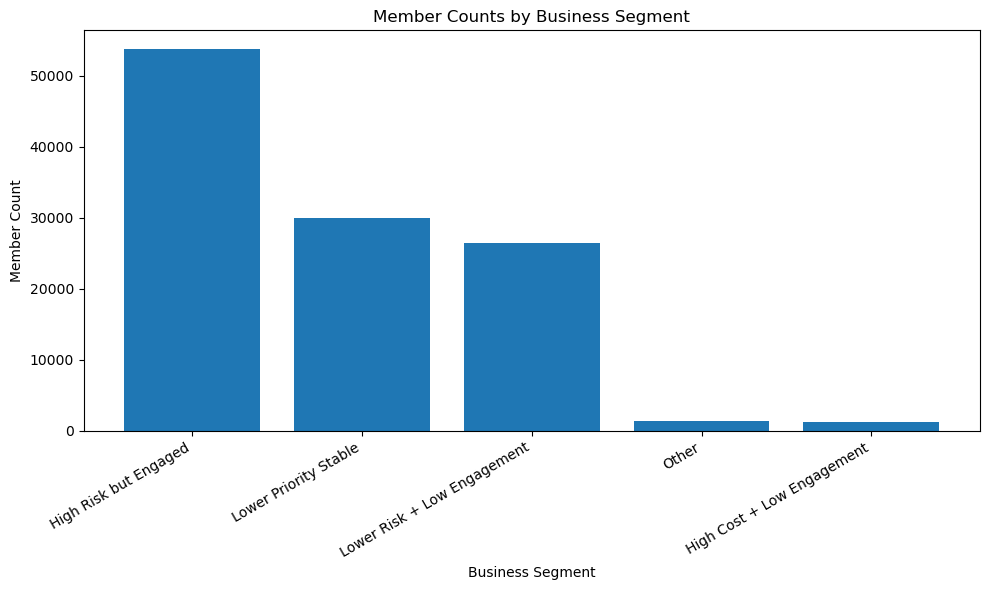

In [22]:
# create chart: business segment counts

plt.figure(figsize=(10, 6))
plt.bar(segment_counts["business_segment"], segment_counts["member_count"])
plt.title("Member Counts by Business Segment")
plt.xlabel("Business Segment")
plt.ylabel("Member Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

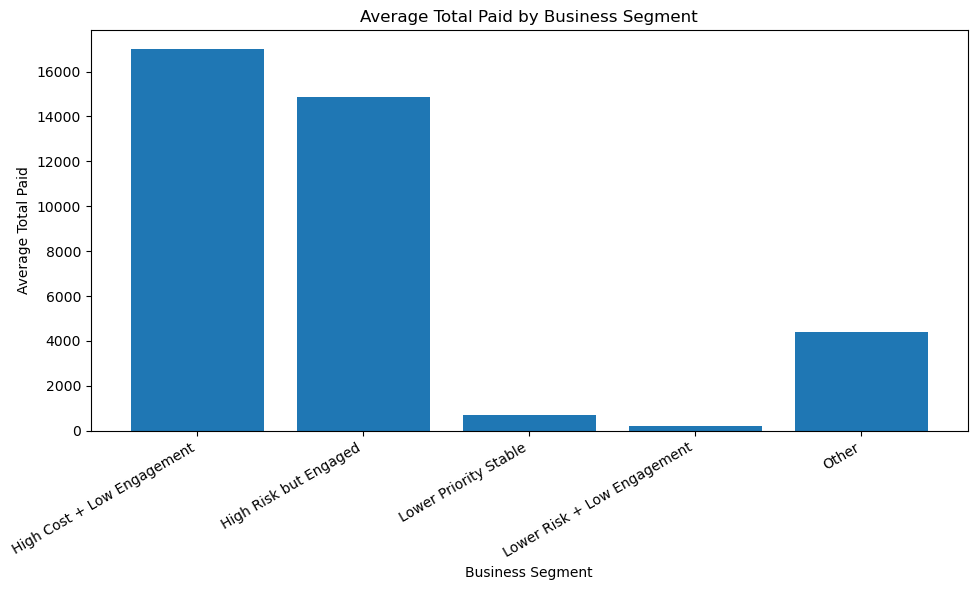

In [23]:
# create chart: average total paid by segment

plt.figure(figsize=(10, 6))
plt.bar(segment_summary["business_segment"], segment_summary["total_paid_all_claims"])
plt.title("Average Total Paid by Business Segment")
plt.xlabel("Business Segment")
plt.ylabel("Average Total Paid")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [24]:
# create chart: outreach priority rate by segment

segment_outreach = (
    df.groupby("business_segment")["outreach_priority_flag"]
    .mean()
    .mul(100)
    .round(2)
    .reset_index()
)

segment_outreach.columns = ["business_segment", "outreach_priority_pct"]
segment_outreach

,business_segment,outreach_priority_pct
0,High Cost + Low Engagement,100.00
1,High Risk but Engaged,0.00
2,Lower Priority Stable,0.00
3,Lower Risk + Low Engagement,1.85
4,Other,86.34


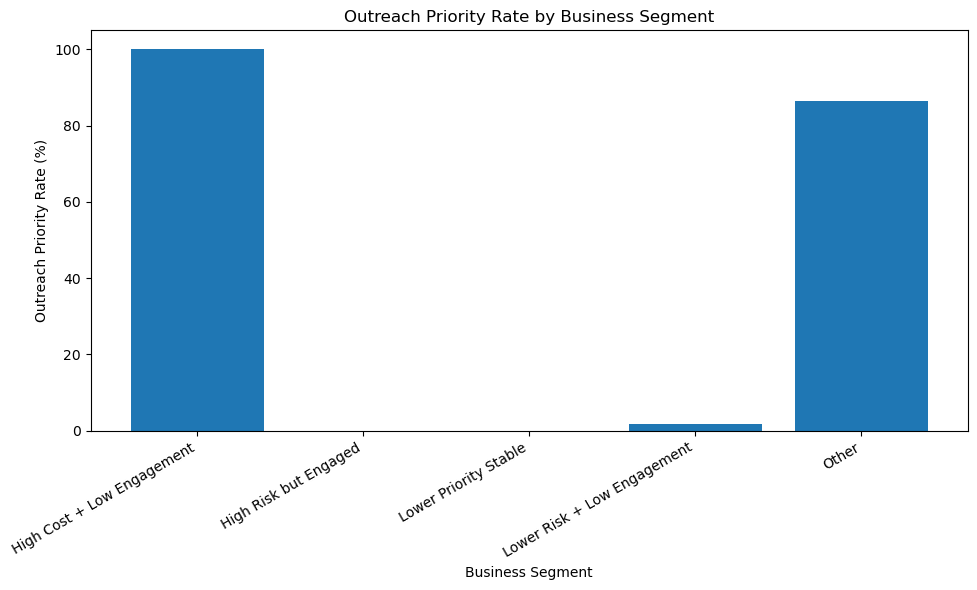

In [25]:
# plot outreach priority rate by segment

plt.figure(figsize=(10, 6))
plt.bar(segment_outreach["business_segment"], segment_outreach["outreach_priority_pct"])
plt.title("Outreach Priority Rate by Business Segment")
plt.xlabel("Business Segment")
plt.ylabel("Outreach Priority Rate (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [26]:
# create summary workbook for tableau/source review

with pd.ExcelWriter(os.path.join(tableau_dir, "business_insights_summary_tables.xlsx")) as writer:
    segment_counts.to_excel(writer, sheet_name="segment_counts", index=False)
    segment_summary.to_excel(writer, sheet_name="segment_summary", index=False)
    risk_engagement_matrix.to_excel(writer, sheet_name="risk_engagement_matrix", index=False)
    chronic_segment_summary.to_excel(writer, sheet_name="chronic_segment_summary", index=False)
    state_summary.to_excel(writer, sheet_name="state_summary", index=False)
    top_outreach_candidates.head(500).to_excel(writer, sheet_name="top_outreach_candidates", index=False)

print("Saved business insights summary workbook.")

Saved business insights summary workbook.


In [27]:
# business insights

print("""
Business-facing insights from this project:
1. Members can be segmented not just by cost risk, but by engagement behavior and outreach need.
2. A high-cost member with low engagement may represent a stronger intervention opportunity than a similarly high-risk but highly engaged member.
3. Chronic burden and utilization patterns help differentiate member segments and likely outreach intensity.
4. Predicted risk bands can support prioritization workflows for care navigation, digital nudges, or case management.
5. Combining claims-derived risk features with engagement indicators creates a more operationally useful view than either data source alone.
""")


Business-facing insights from this project:
1. Members can be segmented not just by cost risk, but by engagement behavior and outreach need.
2. A high-cost member with low engagement may represent a stronger intervention opportunity than a similarly high-risk but highly engaged member.
3. Chronic burden and utilization patterns help differentiate member segments and likely outreach intensity.
4. Predicted risk bands can support prioritization workflows for care navigation, digital nudges, or case management.
5. Combining claims-derived risk features with engagement indicators creates a more operationally useful view than either data source alone.



In [28]:
# README file

insight_lines = [
    "Business-facing insights from this project:",
    "1. Members can be segmented by both cost risk and digital engagement behavior.",
    "2. High-cost, low-engagement members may benefit from prioritized outreach.",
    "3. Chronic burden and utilization patterns are associated with elevated cost risk.",
    "4. Predicted risk bands support operational segmentation and resource prioritization.",
    "5. Combining claims-style data with engagement signals produces more actionable member insights."
]

with open(os.path.join(outputs_dir, "project_key_insights.txt"), "w") as f:
    for line in insight_lines:
        f.write(line + "\n")

print("Saved project_key_insights.txt")

Saved project_key_insights.txt
